# Quickstart Guide: Stress Sequences with the DEPRESS Dataset

This guide walks you through social sequence analysis using real data from the **DEPRESS** study (Dataset on Emotions, Performance, Responses, Environment, and Satisfaction during COVID-19).

**What is DEPRESS?** DEPRESS is a longitudinal dataset on college students’ mental health and learning during the COVID-19 pandemic (Guo et al., 2026, *Scientific Data*). It was collected at Worcester Polytechnic Institute from **June 2020 to June 2021** and includes three cohorts (semesters): **Summer 2020**, **Fall 2020**, and **Spring 2021**. Each participant joined one cohort and completed weekly surveys. Among other measures, participants answered the **4-item Perceived Stress Scale (PSS-4)** each week. In this tutorial we use PSS to build **stress level sequences** over 8 weeks (Low / Medium / High) and see how students cluster into different stress patterns.

New to Python? No problem—Sequenzo is designed to be intuitive and beginner-friendly.

**By the end of this tutorial you will:**

1. Load and explore the stress sequence data
2. Define sequence states (Low, Medium, High) from PSS scores
3. Visualize and compare sequences (index plots, state distribution, mean time, etc.)
4. Run clustering and interpret three clusters of stress trajectories

Let’s get started! 🐍✨


## 1. Get a rough idea of the data

In [28]:
# Import necessary libraries
from sequenzo import * # Import the package, give it a short alias
import pandas as pd # Data manipulation

# Load the data that we would like to explore in this tutorial
# `df` is the short for `dataframe`, which is a common variable name for a dataset
df = load_dataset('students_stress_states_by_week')

# Show the dataframe
df

,participant_id,cohort,1,2,3,4,5,6,7,8,gender,income_group,race,avg_study_time
0,Fall 101,Fall,M,M,M,M,M,L,L,M,male,Middle ($60k–$150k),Other,Higher (T3)
1,Fall 104,Fall,L,L,L,L,L,L,M,L,female,Middle ($60k–$150k),Asian,Higher (T3)
2,Fall 24,Fall,M,M,M,M,L,L,L,L,female,Higher ($150k+),White,Lower (T1)
3,Fall 26,Fall,M,H,H,M,M,M,H,H,female,Middle ($60k–$150k),Asian,Middle (T2)
4,Fall 27,Fall,H,H,M,M,M,M,M,M,male,Middle ($60k–$150k),White,Higher (T3)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Spring 139,Spring,L,L,L,L,L,L,L,L,male,Higher ($150k+),White,Middle (T2)
72,Spring 143,Spring,H,M,H,H,M,M,H,M,female,Middle ($60k–$150k),White,Middle (T2)
73,Spring 144,Spring,L,L,L,L,L,L,L,L,male,Unknown,White,Middle (T2)
74,Spring 147,Spring,M,M,L,L,M,M,L,M,female,Unknown,Prefer not to answer,Lower (T1)


**Income grouping:** The column `income_group` (4 categories: Lower (&lt;$60k), Middle ($60k–$150k), Higher ($150k+), Unknown) is created in the data cleaning pipeline (`code/step7_merge_demographics.py`) and is already included in the loaded dataset.

**How are the three states defined?** In the DEPRESS study, stress was measured each week with the **4-item Perceived Stress Scale (PSS-4)**. PSS-4 responses are coded (e.g. “Never” = 0, “Almost Never” = 1, …, “Very Often” = 4); the score for each week is the average of the four items, so it ranges from **0 to 4**. For sequence analysis, each week’s score is then turned into one of three **states**:

* **Low (L)** – Lower perceived stress (e.g. lower end of the PSS range)
* **Medium (M)** – Moderate perceived stress
* **High (H)** – Higher perceived stress (e.g. higher end of the PSS range)

In social sequence analysis, each of these categories is called a **state**, and the ordered list of states over the 8 weeks is called a **social sequence**. In our dataframe, each **row** is one participant and **columns 1–8** are their stress state in weeks 1–8. For example, a sequence `M, L, L, L, L, L, H, L` means: medium stress in week 1, low in weeks 2–6, high in week 7, and low again in week 8.  

## 2. Analyze Social Sequences with Sequenzo

In [29]:
# Define the time-span variable
time_list = ['1', '2', '3', '4', '5', '6', '7', '8']

states = ['L', 'M', 'H']
labels = ['Low', 'Medium', 'High']
custom_colors = [
  "#74C9B4",  # Low
  "#F9E79F",  # Medium
  "#F5B7B1"   # High
]

sequence_data = SequenceData(df, 
                             time=time_list, 
                             id_col="participant_id", 
                             states=states,
                             labels=labels,
                             custom_colors=custom_colors)

sequence_data


[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 76
[>] Number of time points: 8
[>] Min/Max sequence length: 8 / 8
[>] States: ['L', 'M', 'H']
[>] Labels: ['Low', 'Medium', 'High']
[>] Weights: Not provided


SequenceData(76 sequences, States: ['L', 'M', 'H'])

## Visualization

Among the various visualization methods, the most commonly used one is the **index plot**. Let's see how it works.

Now we have successfully created the `SequenceData` object from our dataframe. This is the core object in Sequenzo for analyzing social sequences.

Looking at the raw data, we can only easily inspect one participant at a time. With Sequenzo, we can analyze and visualize all participants' stress sequences at once. The most important tool is visualization (e.g., the sequence index plot) which helps us see patterns and trends, such as which weeks tend to be high-stress and how stress evolves over the 8 weeks.

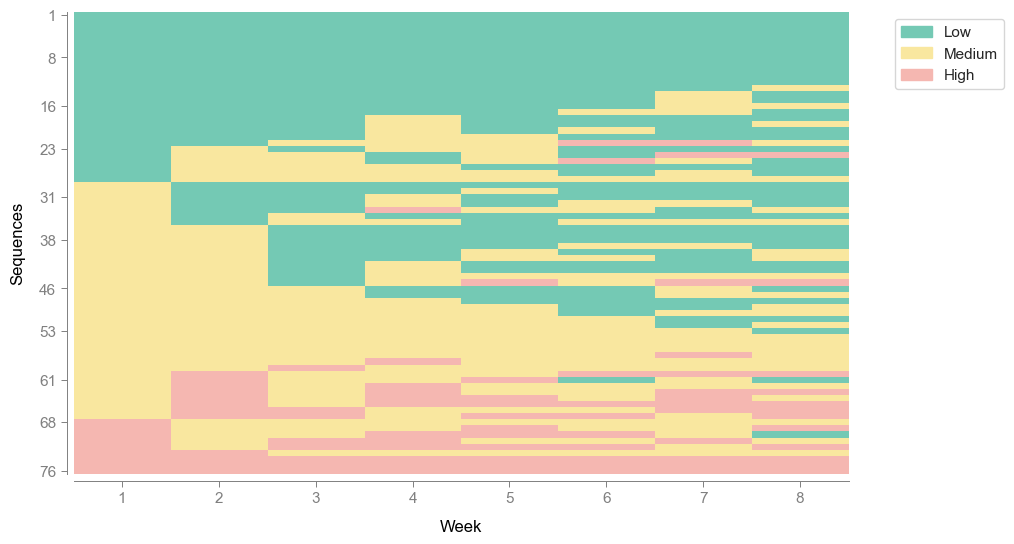

In [30]:
# Plot the index plot
plot_sequence_index(sequence_data, 
                    xlabel='Week',
                    save_as='index_plot',
                    dpi=300)

[>] Reminder: You passed `group_column_name` but not `group_dataframe`.
    • `group_column_name` is used together with `group_dataframe` (e.g. a separate table with cluster membership).
    • To group by a column that is already in your sequence data, use `group_by_column` instead (e.g. group_by_column='cohort').
    Proceeding with a single (ungrouped) plot.


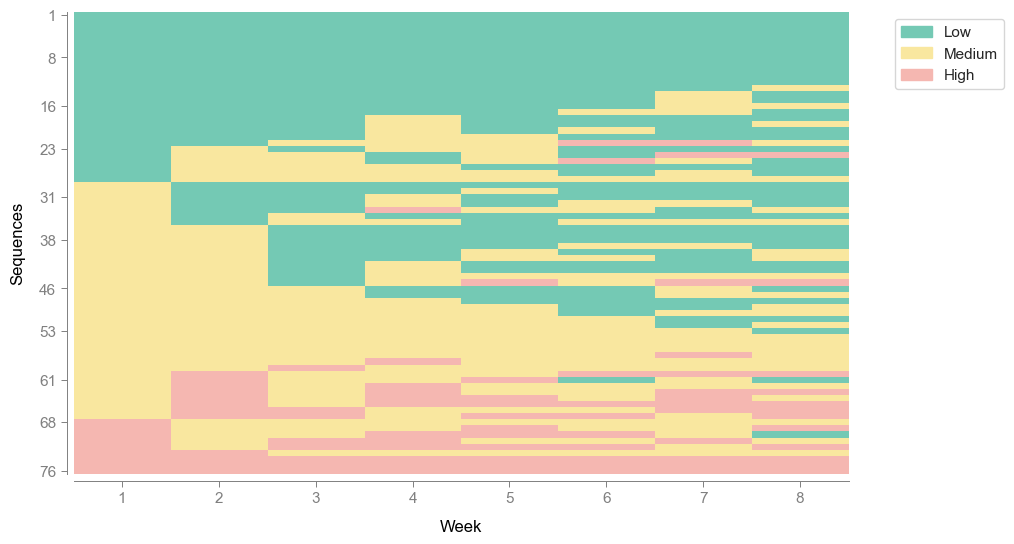

In [31]:
# Plot the index plot

plot_sequence_index(sequence_data, 
                    group_column_name='cohort',
                    xlabel='Week',
                    # save_as='index_plot',
                    )

[>] Creating grouped plots by 'gender' with 2 categories


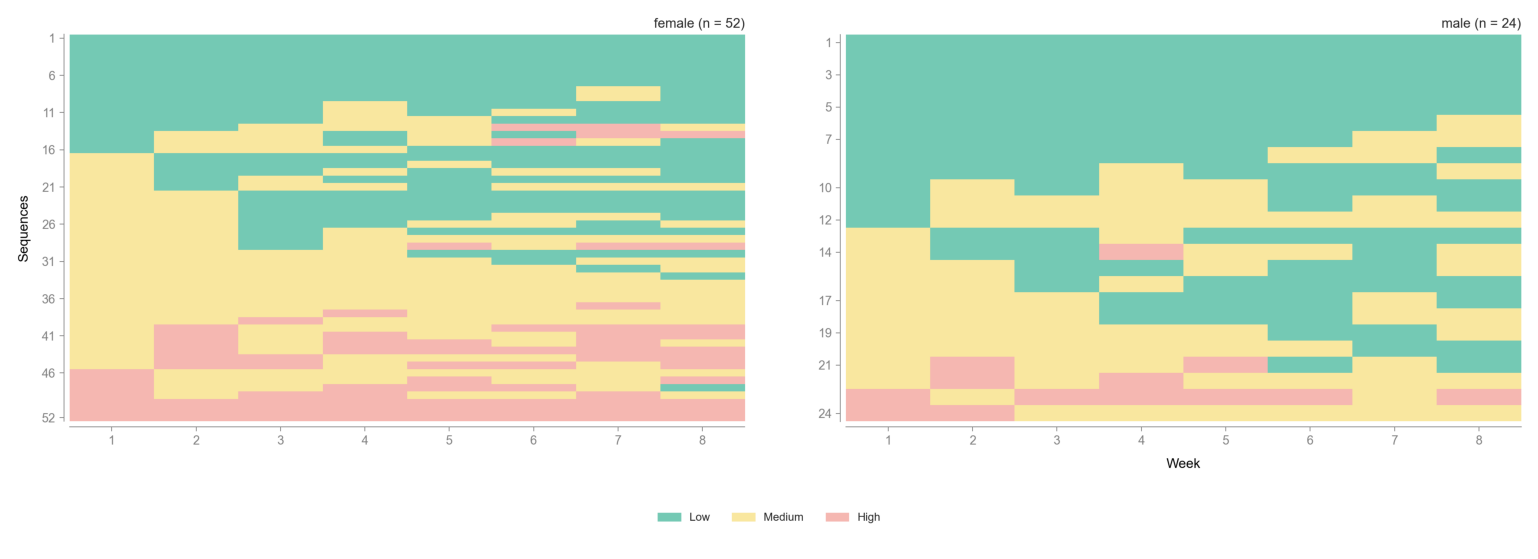

In [32]:
# Plot the index plot

plot_sequence_index(sequence_data, 
                    group_by_column='gender',
                    xlabel='Week',
                    # save_as='index_plot',
                    )

[>] Creating grouped plots by 'race' with 5 categories


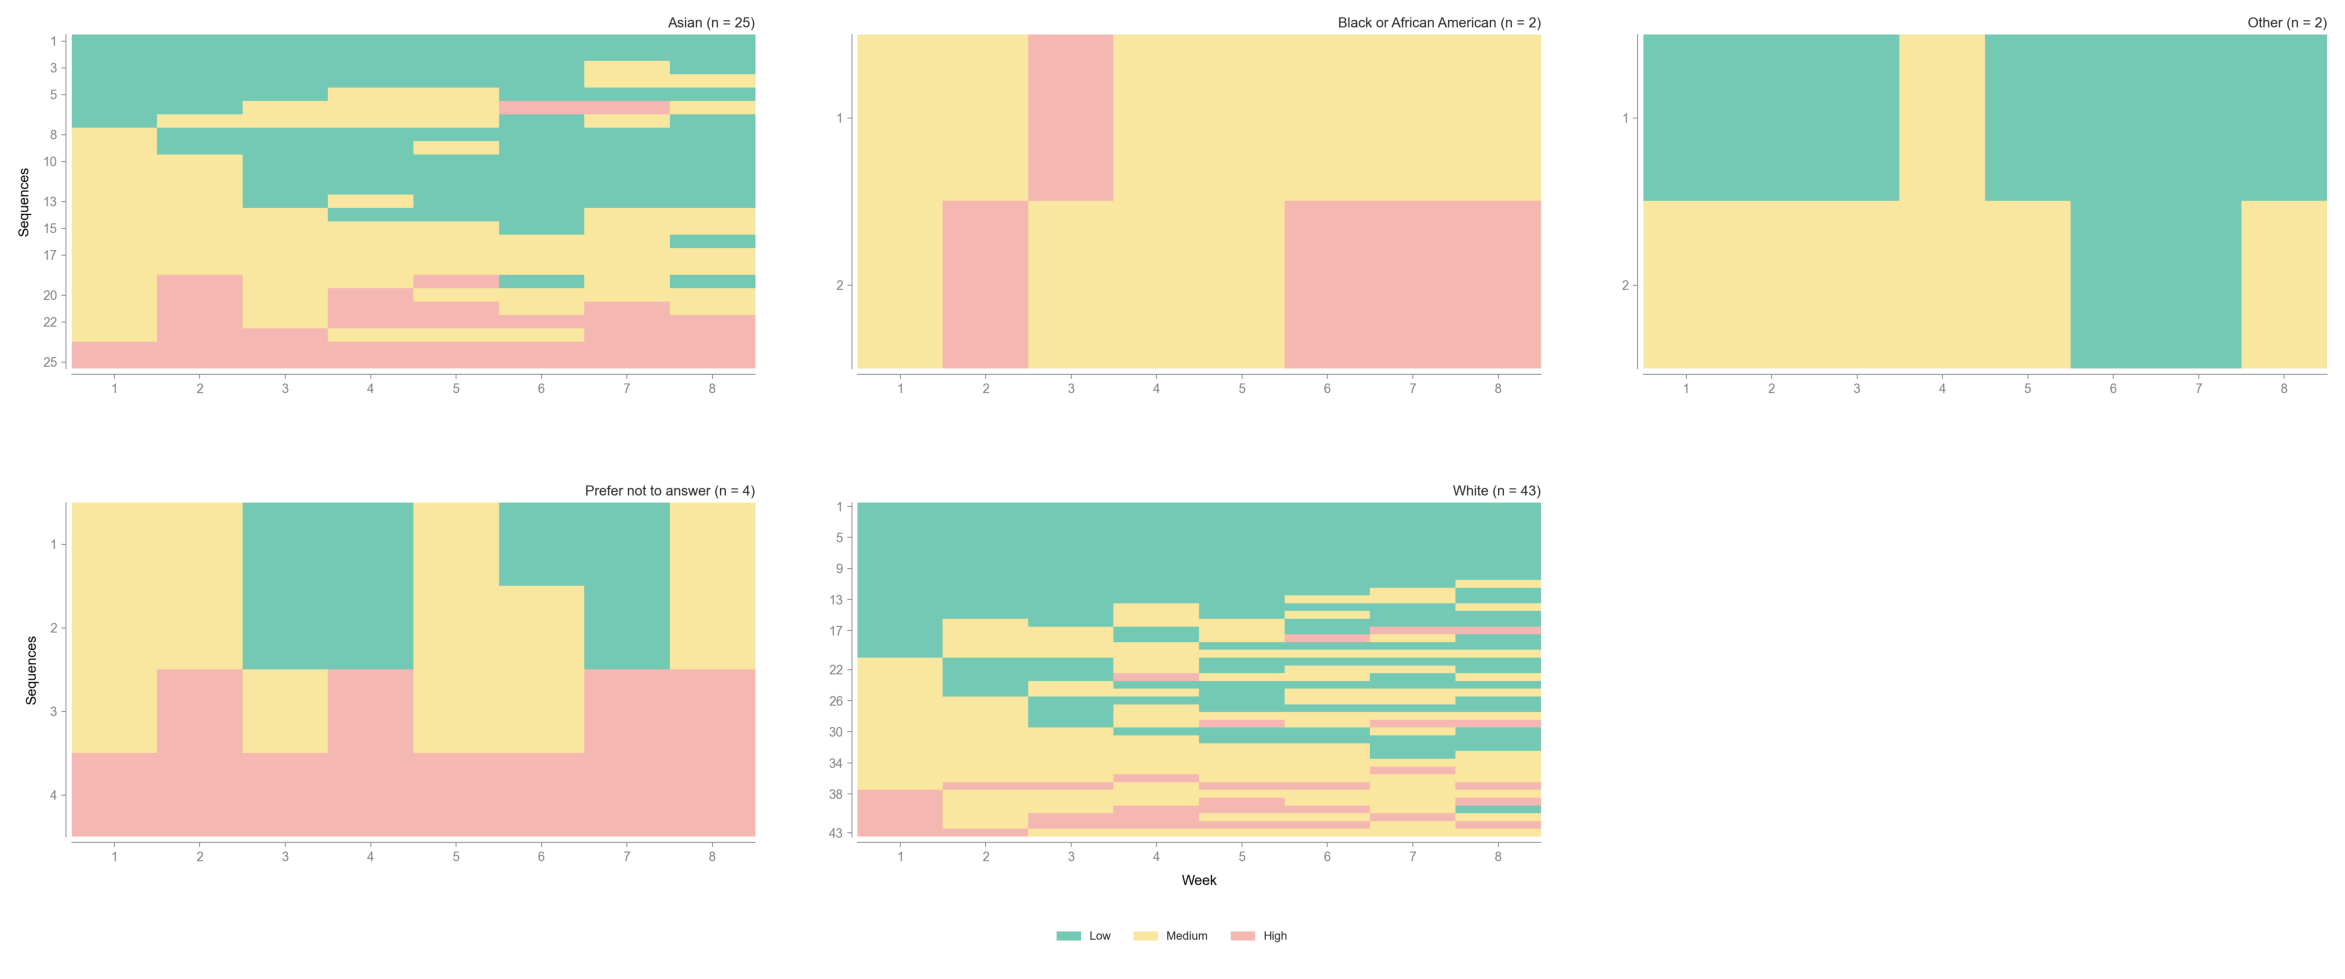

In [33]:
# Plot the index plot

plot_sequence_index(sequence_data, 
                    group_by_column='race',
                    xlabel='Week',
                    # save_as='index_plot',
                    )

[>] Creating grouped plots by 'income_group' with 4 categories


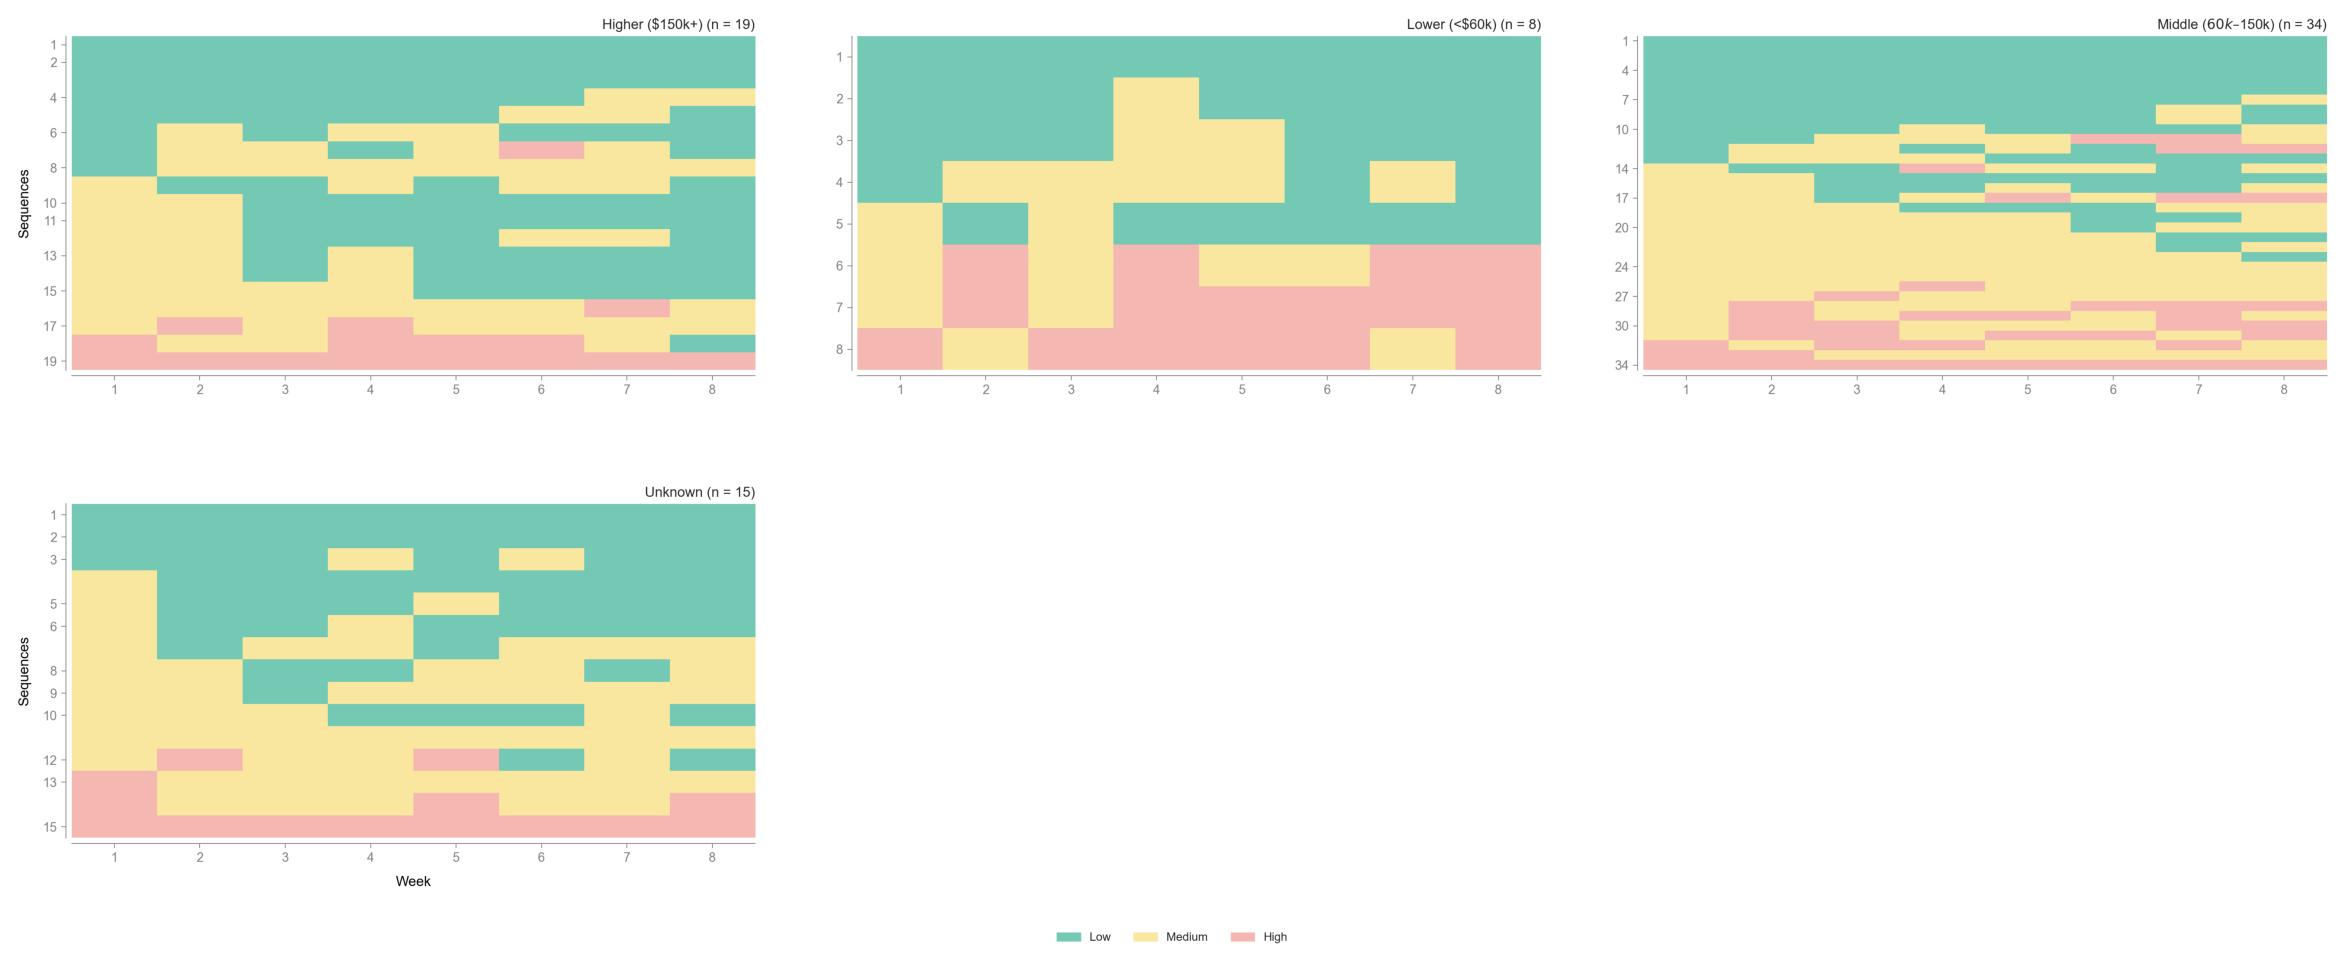

In [34]:
# Plot the index plot (by income_group: fewer, merged categories)

plot_sequence_index(sequence_data, 
                    group_by_column='income_group',
                    xlabel='Week',
                    # save_as='index_plot',
                    )

[>] Creating grouped plots by 'avg_study_time' with 3 categories


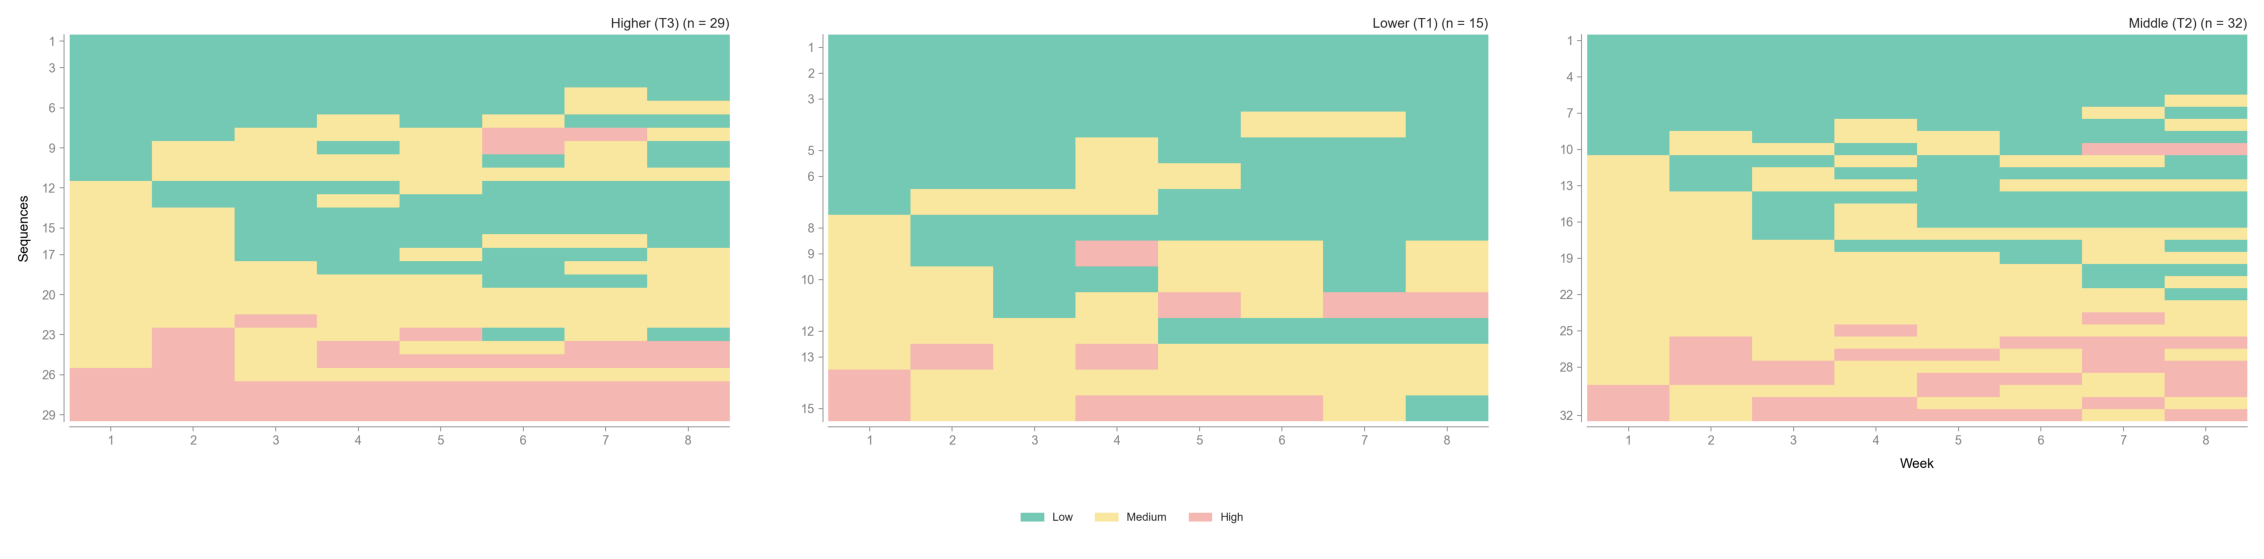

In [35]:
# Plot the index plot

plot_sequence_index(sequence_data, 
                    group_by_column='avg_study_time',
                    xlabel='Week',
                    # save_as='index_plot'
                    )

Stress heterogeneity appears structurally stable across pandemic stages.

But what if we would like to know more? state distribution plot. 

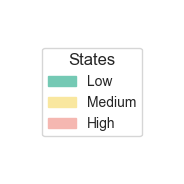

In [36]:
sequence_data.plot_legend(
                        # save_as="legend_plot"
                        )

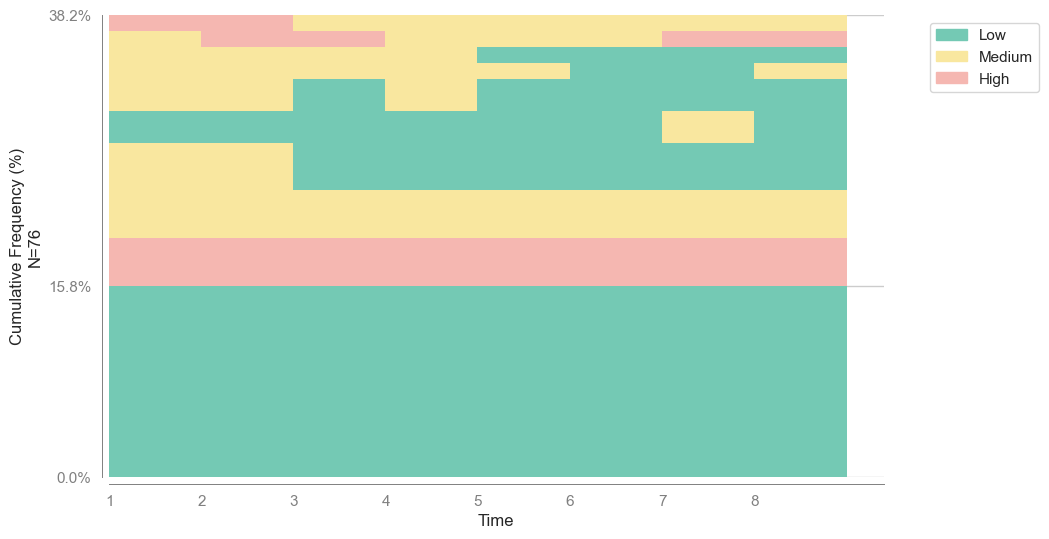

In [37]:
# Note: `plot_most_frequent_sequences` does not divide frequencies evenly; it’s just that in the stress data, the top sequences vary in frequency.

plot_most_frequent_sequences(sequence_data, top_n=10)

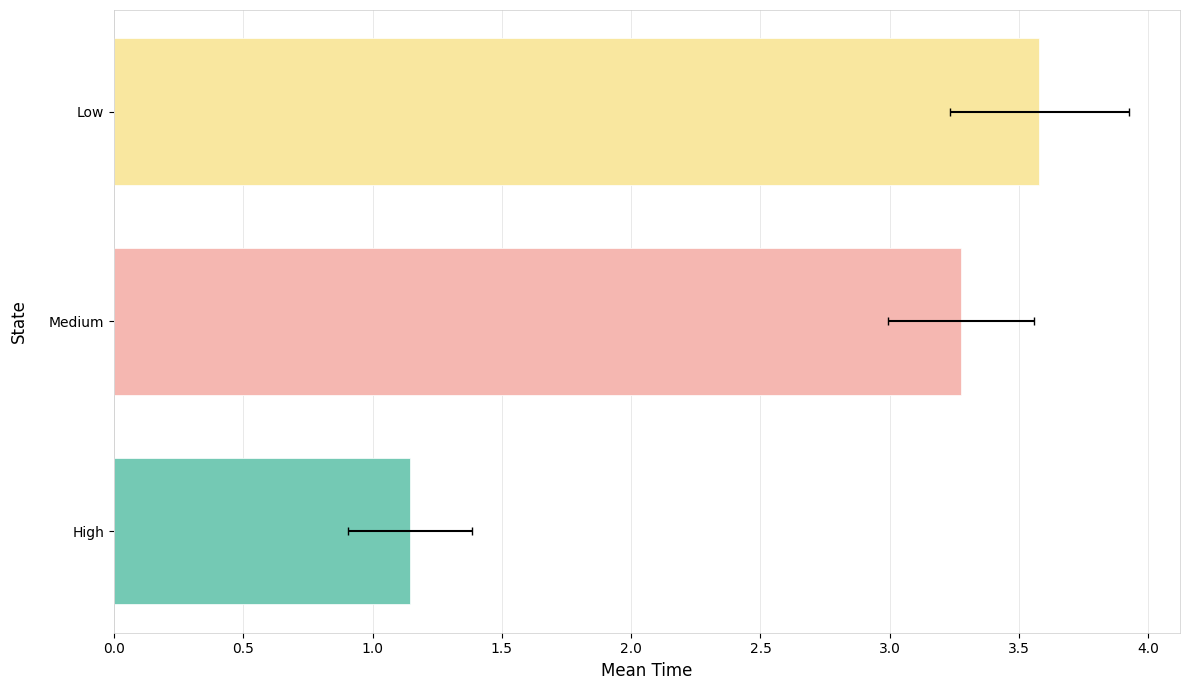

In [38]:
plot_mean_time(sequence_data,
               # save_as='mean_time'
               )

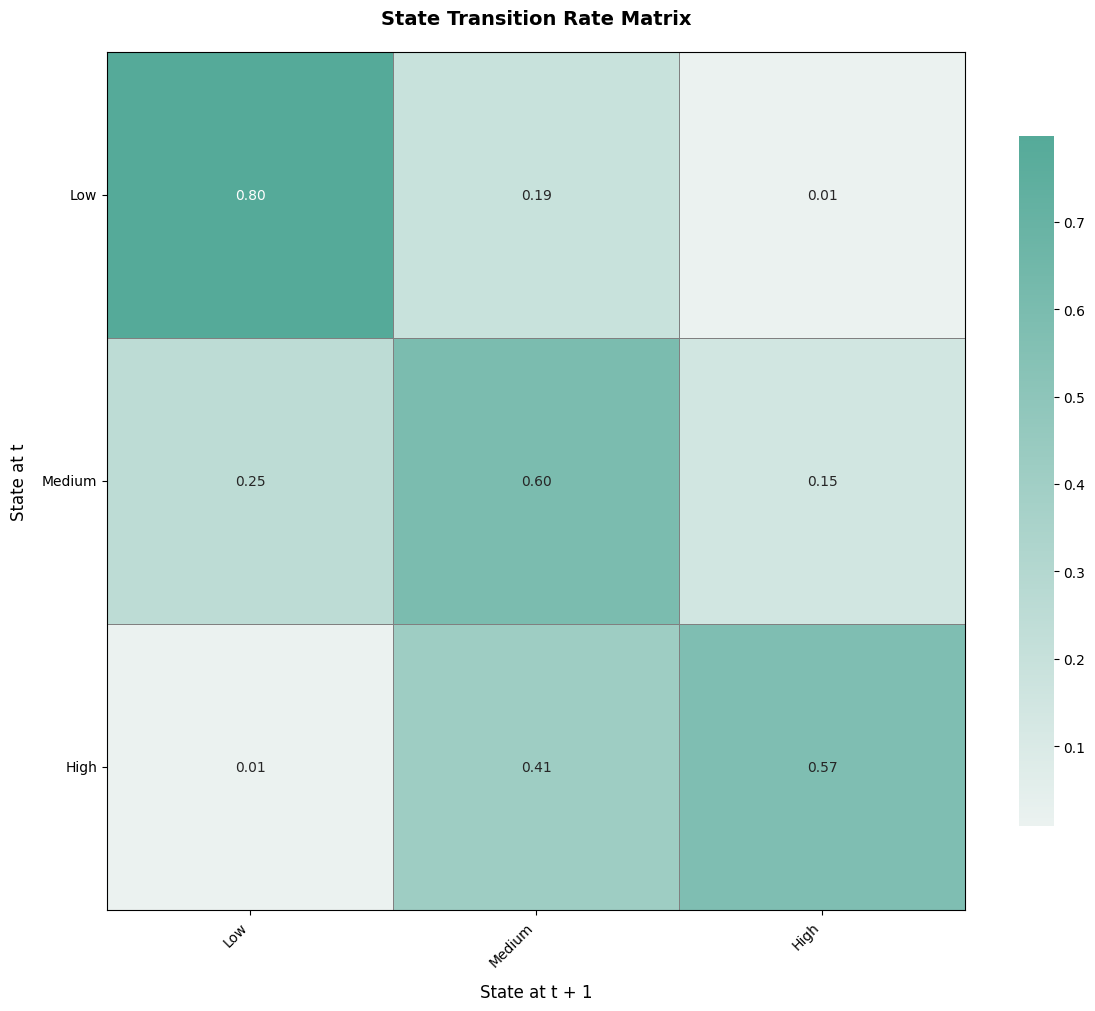

In [39]:
plot_transition_matrix(sequence_data)


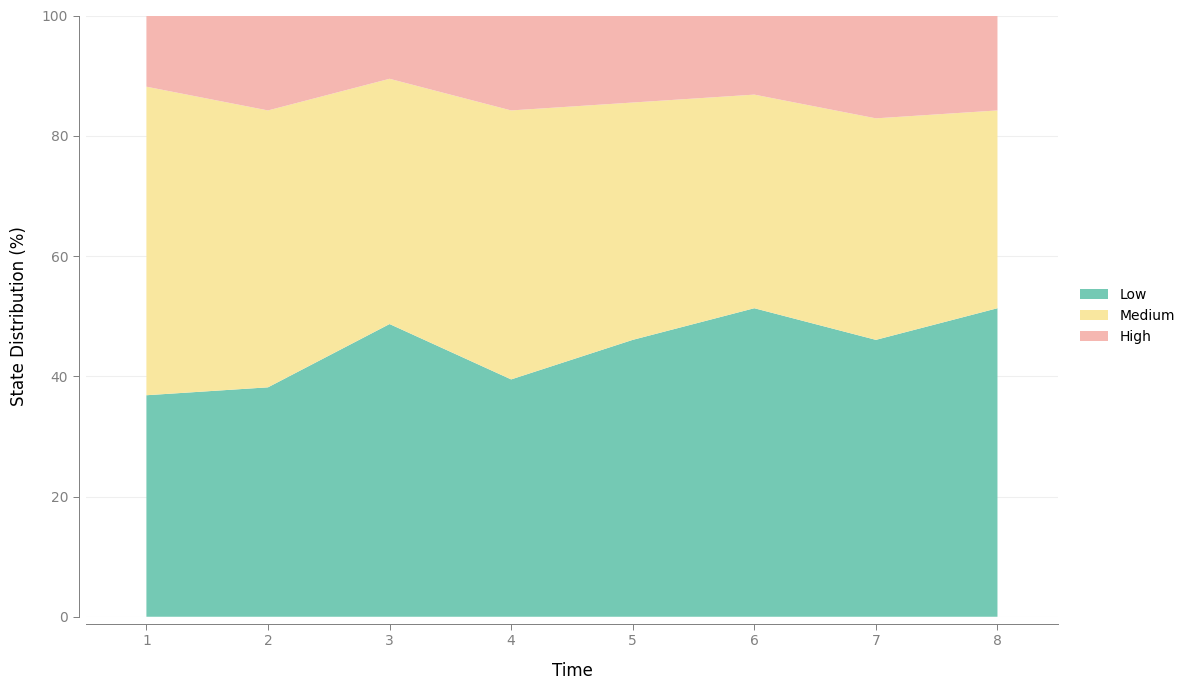

In [40]:
plot_state_distribution(sequence_data)

[>] Creating grouped plots by 'income_group' with 4 categories


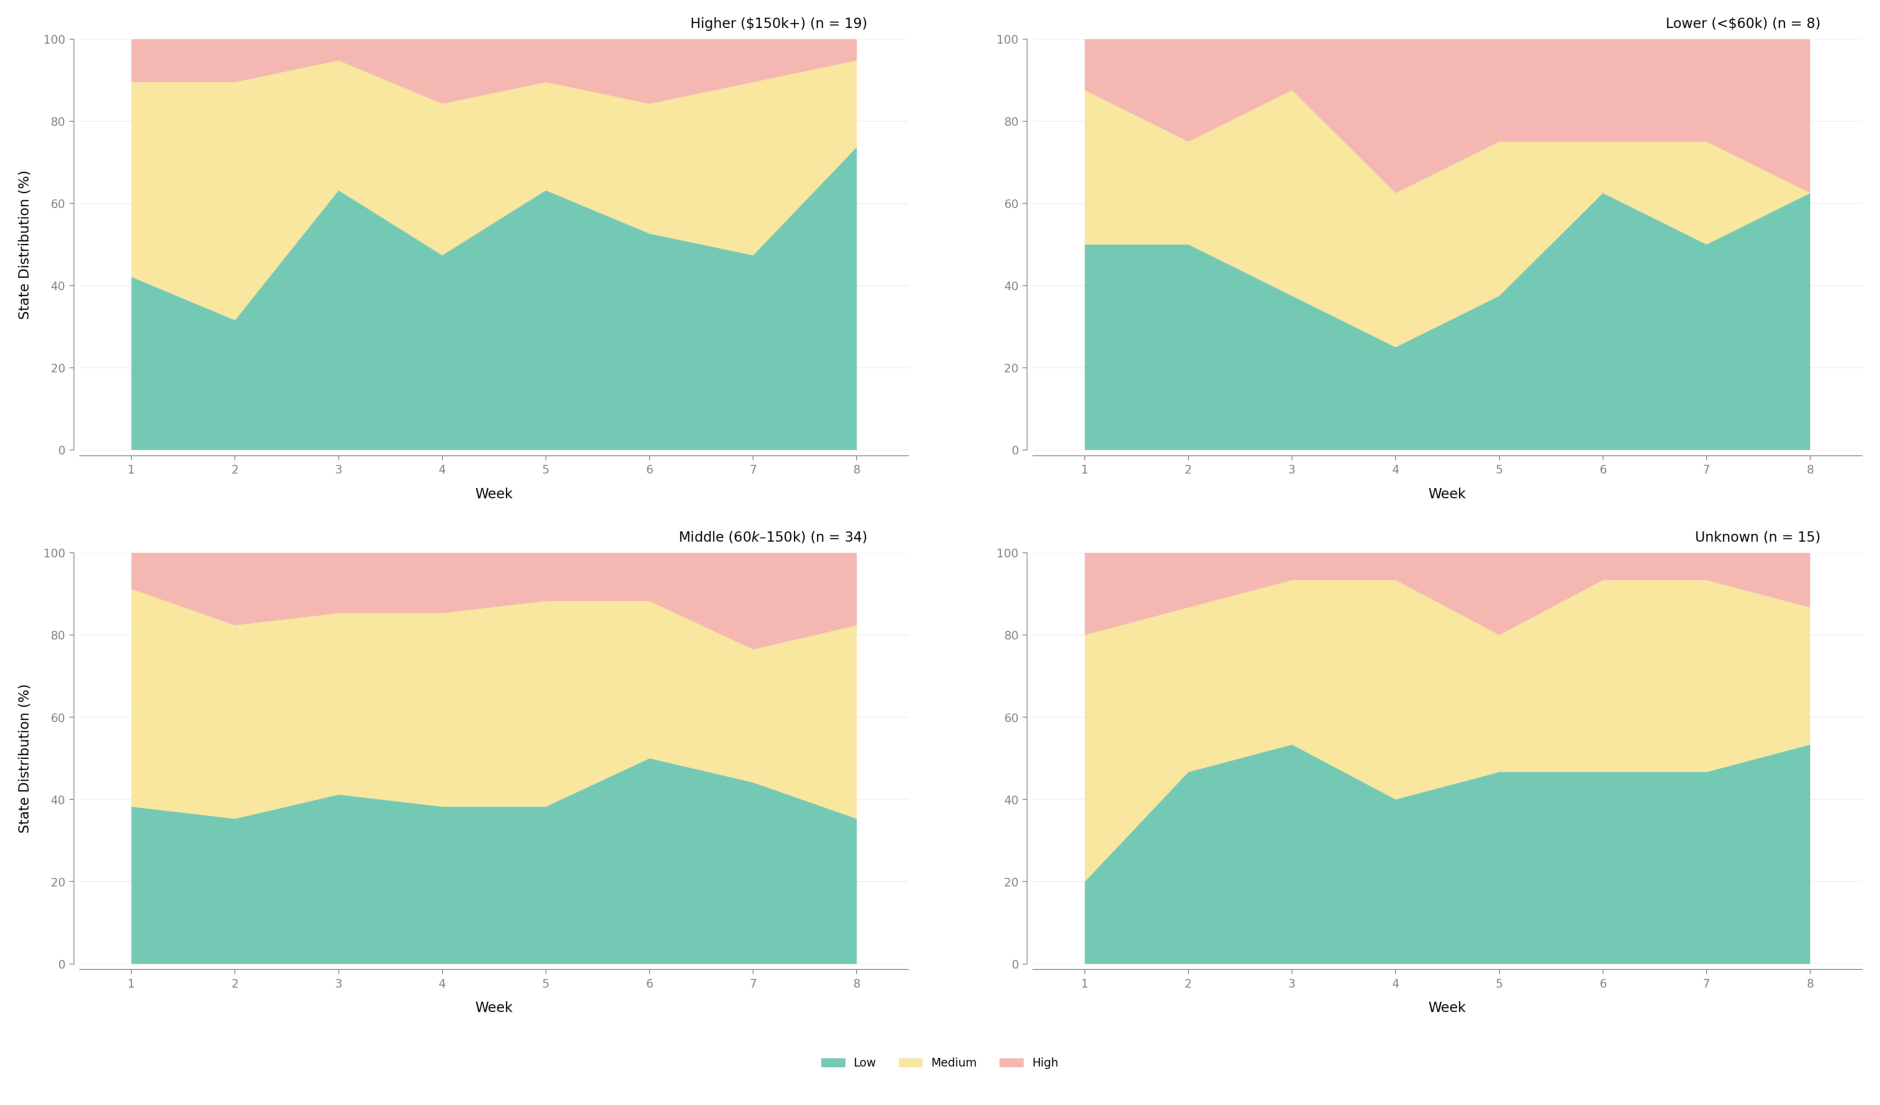

In [41]:
plot_state_distribution(sequence_data,
                        group_by_column='income_group',
                        nrows=2,
                        ncols=2,
                        xlabel='Week',
                        )

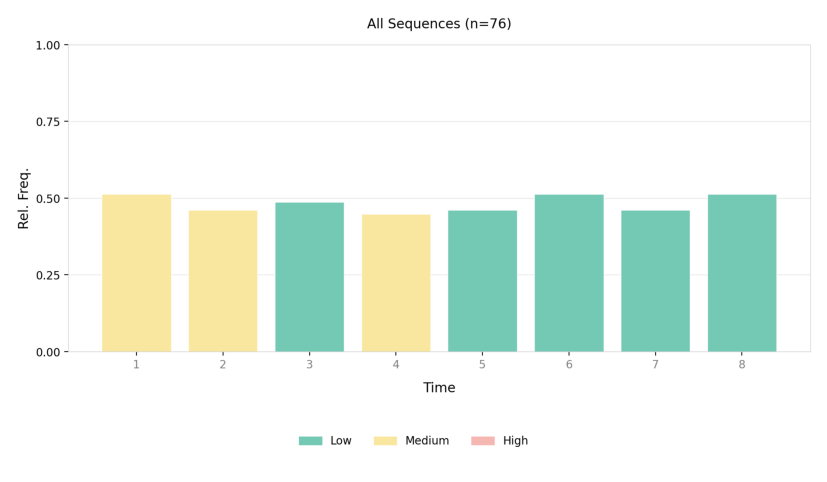

In [42]:
plot_modal_state(sequence_data)

## Dissimilarity Measures

In [43]:
# You can also replace "OMspell" with "OM/DHD/HAM" and "TRATE" with "CONSTANT"
om = get_distance_matrix(seqdata=sequence_data,
                         method="OM",
                         sm="TRATE",
                         indel="auto")
om

[>] Processing 76 sequences with 3 unique states.
[>] Transition-based substitution-cost matrix (TRATE) initiated...
  - Computing transition probabilities for: [L, M, H]
[>] generated an indel of type number

[>] Identified 57 unique sequences.
[>] Starting Optimal Matching(OM)...
[>] Computing all pairwise distances...
[>] Computed Successfully.


,Fall 101,Fall 104,Fall 24,Fall 26,Fall 27,Fall 28,Fall 29,Fall 30,Fall 31,Fall 32,...,Spring 130,Spring 131,Spring 132,Spring 134,Spring 137,Spring 139,Spring 143,Spring 144,Spring 147,Spring 149
Fall 101,0.000000,8.187694,3.104805,6.834856,3.956166,8.187694,1.978083,3.530486,1.552403,9.314416,...,3.530486,6.209611,7.762013,4.969831,3.530486,9.314416,6.834856,9.314416,3.530486,5.508569
Fall 104,8.187694,0.000000,6.635291,12.569540,11.718179,1.552403,9.740096,11.292499,9.314416,1.552403,...,9.314416,3.530486,1.978083,6.635291,4.657208,1.552403,12.569540,1.552403,6.635291,4.657208
Fall 24,3.104805,6.635291,0.000000,7.912332,7.060971,7.060971,3.104805,6.635291,4.657208,6.209611,...,6.635291,3.104805,4.657208,6.947914,1.978083,6.209611,7.912332,6.209611,5.508569,3.956166
Fall 26,6.834856,12.569540,7.912332,0.000000,4.856773,11.017137,6.834856,6.296119,6.296119,14.121943,...,6.296119,11.017137,12.569540,5.934249,7.912332,14.121943,3.417428,14.121943,7.373594,7.912332
Fall 27,3.956166,11.718179,7.060971,4.856773,0.000000,10.165777,3.956166,1.439345,3.417428,13.270582,...,3.417428,10.165777,11.718179,6.947914,7.060971,13.270582,4.856773,13.270582,5.508569,7.060971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Spring 139,9.314416,1.552403,6.209611,14.121943,13.270582,3.104805,9.314416,12.844902,10.866819,0.000000,...,10.866819,3.104805,1.552403,8.187694,6.209611,0.000000,14.121943,0.000000,7.762013,6.209611
Spring 143,6.834856,12.569540,7.912332,3.417428,4.856773,11.017137,6.834856,4.318036,6.296119,14.121943,...,6.296119,11.017137,12.569540,5.934249,7.912332,14.121943,0.000000,14.121943,7.373594,7.912332
Spring 144,9.314416,1.552403,6.209611,14.121943,13.270582,3.104805,9.314416,12.844902,10.866819,0.000000,...,10.866819,3.104805,1.552403,8.187694,6.209611,0.000000,14.121943,0.000000,7.762013,6.209611
Spring 147,3.530486,6.635291,5.508569,7.373594,5.508569,6.635291,4.657208,5.082888,3.530486,7.762013,...,3.104805,4.657208,6.635291,1.978083,3.530486,7.762013,7.373594,7.762013,0.000000,1.978083


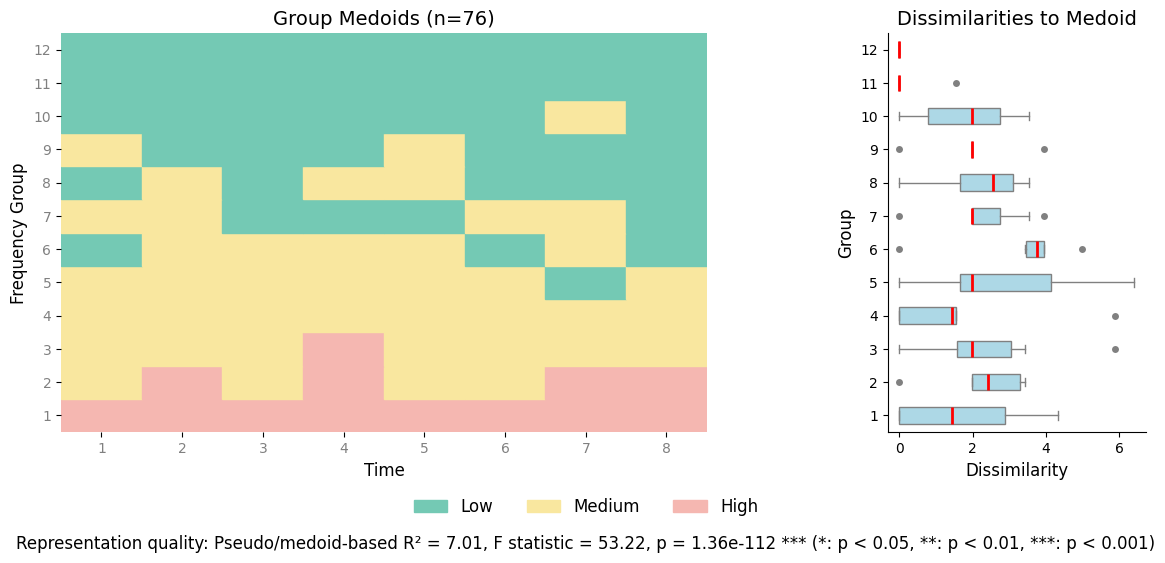

In [44]:
plot_relative_frequency(seqdata=sequence_data, 
                        distance_matrix=om, 
                        num_groups=12, 
                        dpi=200, 
                        # save_as='relative_frequency_plot'
                        )

## Cluster Analysis

[>] Converting DataFrame to NumPy array...


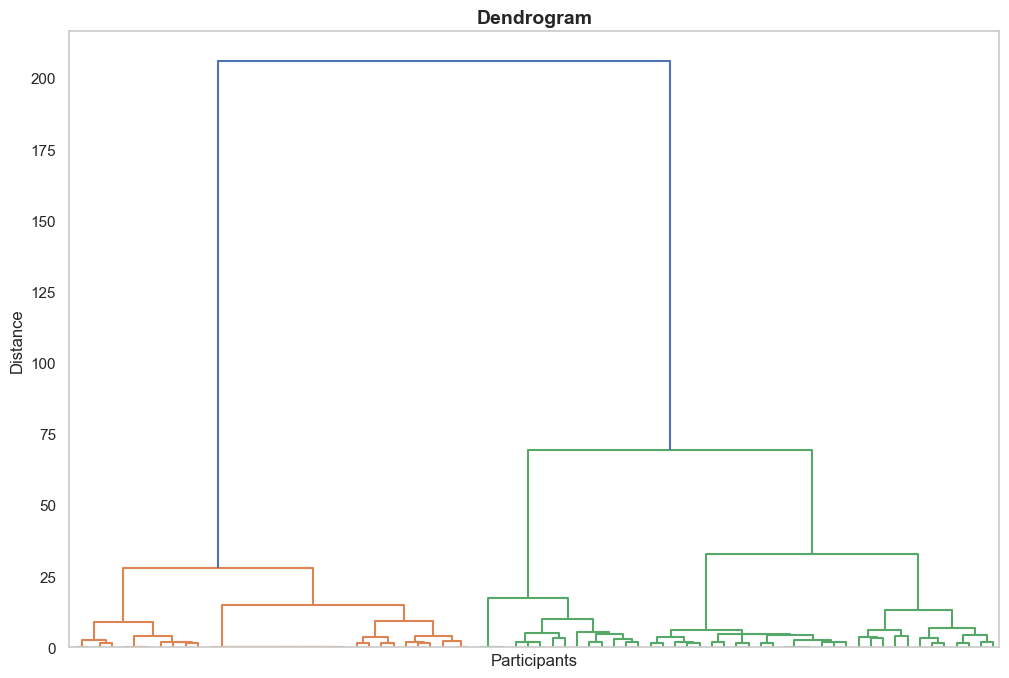

In [45]:
cluster = Cluster(om, sequence_data.ids, clustering_method='ward_d')
cluster.plot_dendrogram(xlabel="Participants", ylabel="Distance")

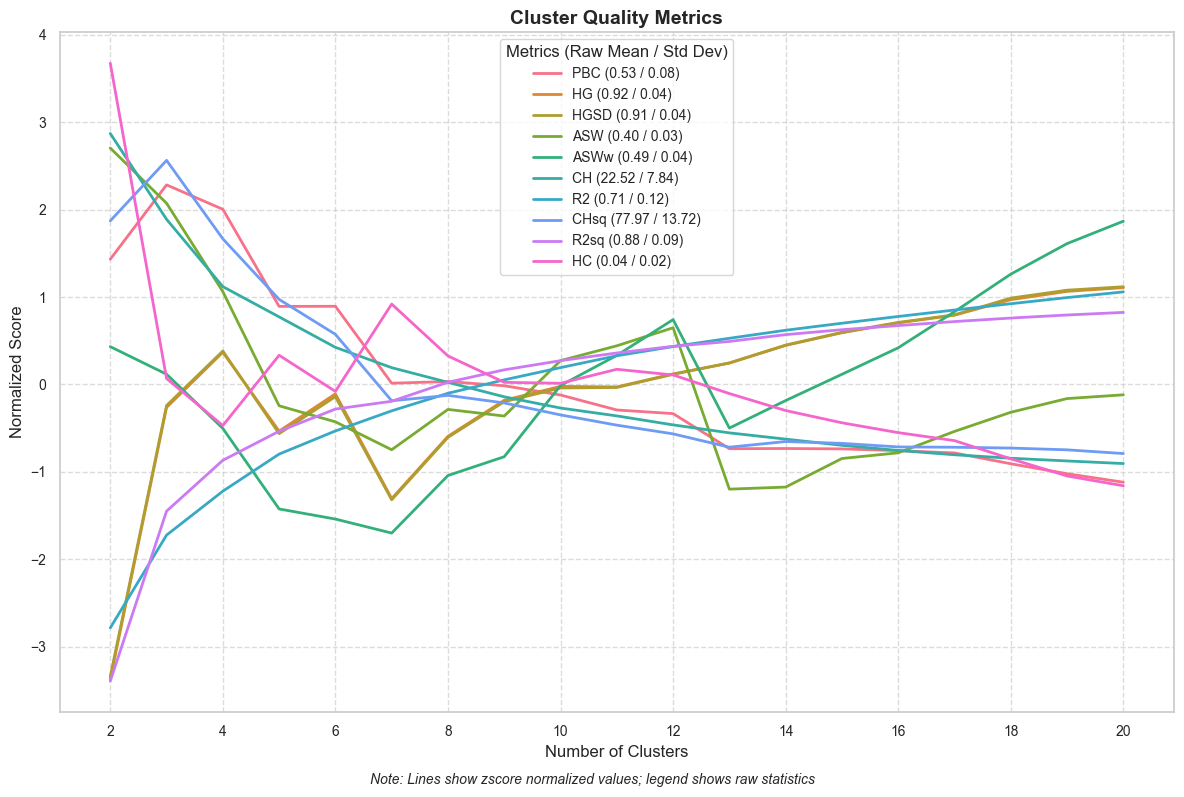

  Metric  Opt. Clusters   Raw Value  Z-Score Norm.
0    PBC              3    0.715334       2.282108
1     HG             20    0.965456       1.106719
2   HGSD             20    0.960524       1.117153
3    ASW              2    0.496260       2.703518
4   ASWw             20    0.565956       1.866664
5     CH              2   45.028721       2.869928
6     R2             20    0.839588       1.058296
7   CHsq              3  113.134507       2.562481
8   R2sq             20    0.957940       0.823764
9     HC              2    0.112005       3.673392


In [46]:
# Create a ClusterQuality object to evaluate clustering quality
cluster_quality = ClusterQuality(cluster)

cluster_quality.compute_cluster_quality_scores()

cluster_quality.plot_cqi_scores(norm='zscore')

summary_table = cluster_quality.get_cqi_table()

print(summary_table)

     Entity ID  Cluster
0     Fall 101        3
1     Fall 104        1
2      Fall 24        1
3      Fall 26        2
4      Fall 27        3
..         ...      ...
71  Spring 139        1
72  Spring 143        2
73  Spring 144        1
74  Spring 147        3
75  Spring 149        3

[76 rows x 2 columns]
   Cluster  Count  Percentage
0        1     33       43.42
1        2     14       18.42
2        3     29       38.16


/opt/anaconda3/envs/sequenzo_test/lib/python3.11/site-packages/sequenzo/clustering/hierarchical_clustering.py:1183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Cluster', y=y_column, data=distribution, palette='pastel')


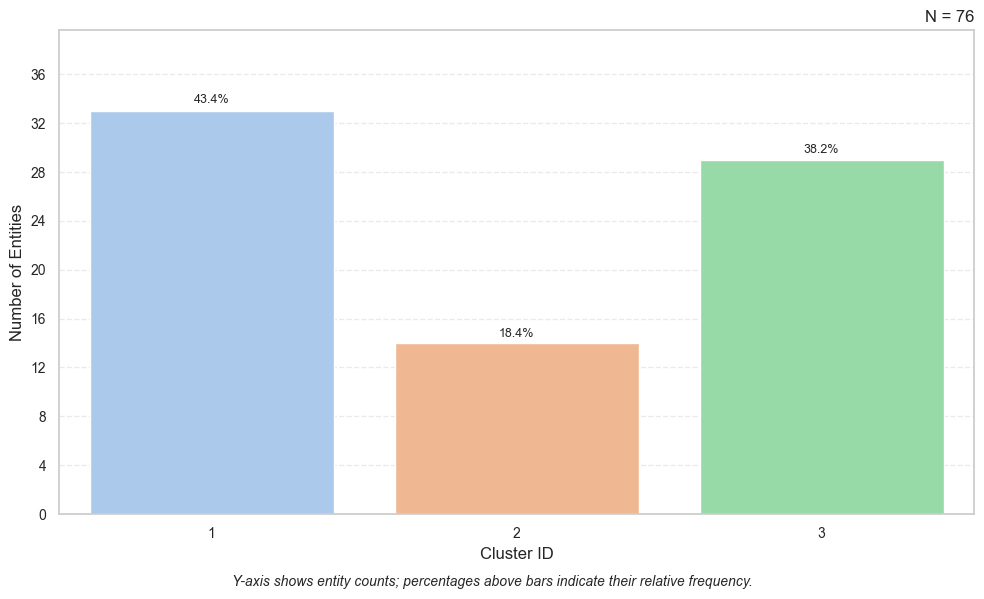

In [47]:
cluster_results = ClusterResults(cluster)

membership_table = cluster_results.get_cluster_memberships(num_clusters=3)

print(membership_table)

distribution = cluster_results.get_cluster_distribution(num_clusters=3)

print(distribution)

cluster_results.plot_cluster_distribution(num_clusters=3, title=None)


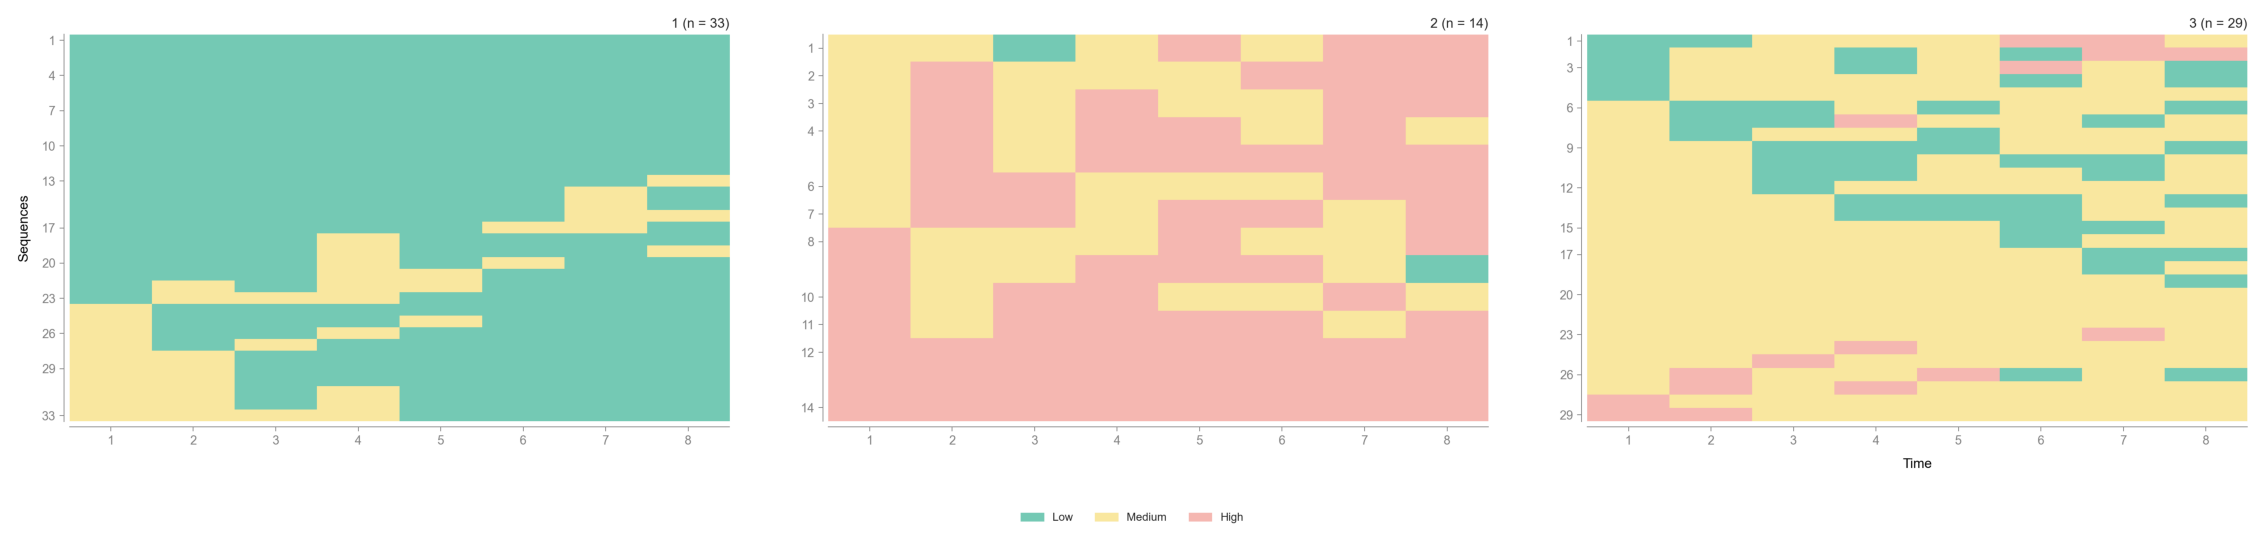

In [48]:
plot_sequence_index(seqdata=sequence_data,
                    group_dataframe=membership_table,
                    group_column_name="Cluster",
                    )

We summarize the **three clusters** of stress trajectories as follows:

**Cluster 1 (Stable Low)** – Most sequences in this cluster stay in the **Low** (green) stress state across the 8 weeks. Some participants have short spells of **Medium** (yellow), and only rarely **High** (orange). This group represents students who maintained low perceived stress for most of the period.

**Cluster 2 (Sustained High)** – This cluster is dominated by **High** (orange) stress, especially from around week 3 onward. In the first weeks there is often a mix of **Medium** (yellow) and **High**; many students then shift to and stay in **High**. **Low** (green) appears only as brief dips. These are students who reported elevated stress for much of the 8 weeks.

**Cluster 3 (Mixed and Fluctuating)** – Here we see a mix of all three states and more change over time. **Medium** (yellow) is often a baseline, with frequent transitions to **Low** (green) or **High** (orange). There is no single long-term stable pattern; trajectories vary a lot within the cluster. This group captures students with more variable stress over the 8 weeks.

In [49]:
cluster_labels = {
    1: 'Stable Low',
    2: 'Sustained High',
    3: 'Mixed and Fluctuating',
}

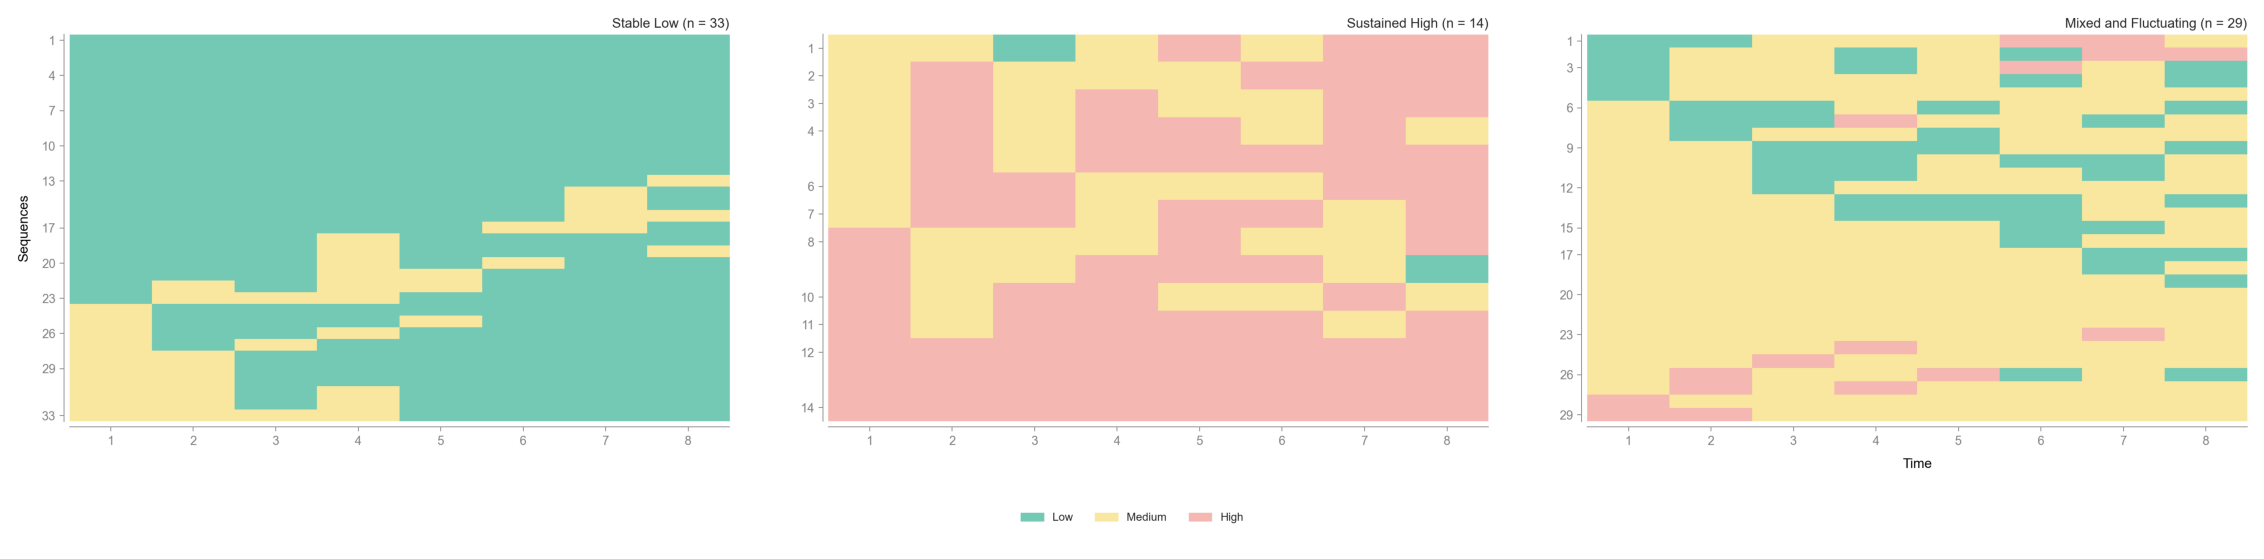

In [50]:
plot_sequence_index(seqdata=sequence_data,
                    group_dataframe=membership_table,
                    group_column_name="Cluster",
                    group_labels=cluster_labels,
                    )

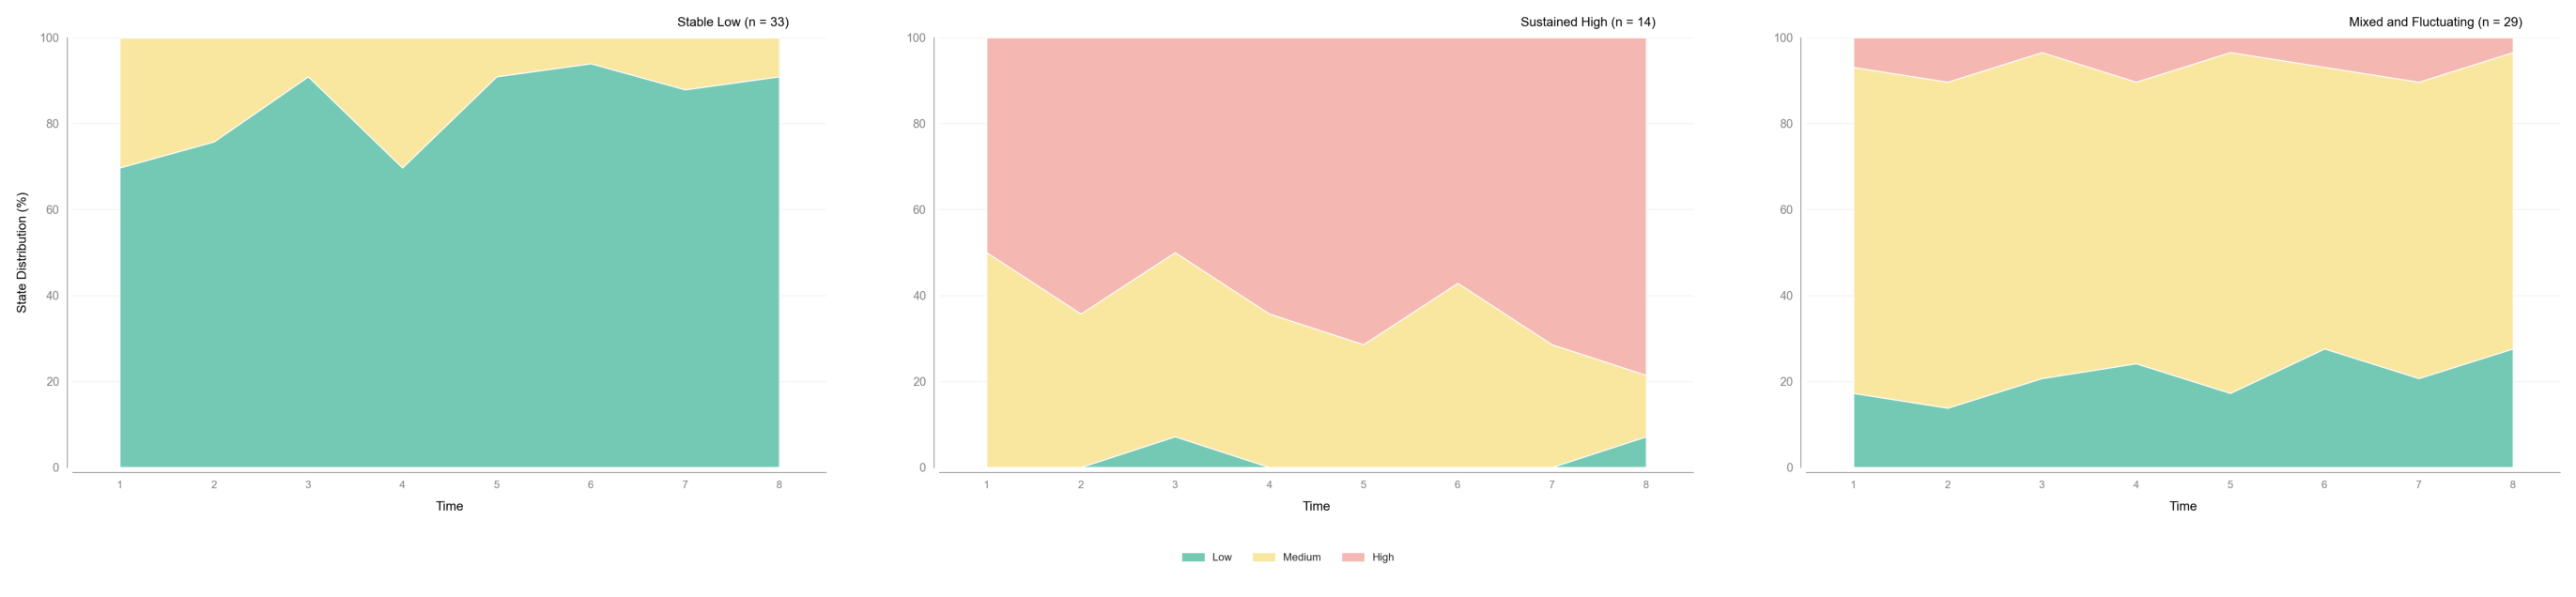

In [51]:
plot_state_distribution(seqdata=sequence_data,
                        group_dataframe=membership_table,
                        group_column_name="Cluster",
                        group_labels=cluster_labels,
                        # save_as='cluster_state_distribution_plot'
                        )

In [52]:
# Prepare the dataframe for regression analysis

membership_table.rename(columns={'Entity ID': 'participant_id'}, inplace=True)

df_with_membership = pd.merge(df, membership_table, on='participant_id', how='left')

# Add an additional column to the dataframe, i.e., the values of Cluster to the labels
df_with_membership['Cluster_labels'] = df_with_membership['Cluster'].map(cluster_labels)

df_with_membership

,participant_id,cohort,1,2,3,4,5,6,7,8,gender,income_group,race,avg_study_time,Cluster,Cluster_labels
0,Fall 101,Fall,M,M,M,M,M,L,L,M,male,Middle ($60k–$150k),Other,Higher (T3),3,Mixed and Fluctuating
1,Fall 104,Fall,L,L,L,L,L,L,M,L,female,Middle ($60k–$150k),Asian,Higher (T3),1,Stable Low
2,Fall 24,Fall,M,M,M,M,L,L,L,L,female,Higher ($150k+),White,Lower (T1),1,Stable Low
3,Fall 26,Fall,M,H,H,M,M,M,H,H,female,Middle ($60k–$150k),Asian,Middle (T2),2,Sustained High
4,Fall 27,Fall,H,H,M,M,M,M,M,M,male,Middle ($60k–$150k),White,Higher (T3),3,Mixed and Fluctuating
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Spring 139,Spring,L,L,L,L,L,L,L,L,male,Higher ($150k+),White,Middle (T2),1,Stable Low
72,Spring 143,Spring,H,M,H,H,M,M,H,M,female,Middle ($60k–$150k),White,Middle (T2),2,Sustained High
73,Spring 144,Spring,L,L,L,L,L,L,L,L,male,Unknown,White,Middle (T2),1,Stable Low
74,Spring 147,Spring,M,M,L,L,M,M,L,M,female,Unknown,Prefer not to answer,Lower (T1),3,Mixed and Fluctuating


## Regression

In [53]:
# Binary logistic regression: one model per cluster (member of cluster vs not)
# Each model: Y=1 if in that cluster, Y=0 otherwise. Predictors: gender, income_group, race, avg_study_time
# (school_year excluded: no effects found in index plot or regression)
#
# Two approaches: (1) MLE (statsmodels) to check convergence; (2) L2-regularized (sklearn) as fallback

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from sklearn.linear_model import LogisticRegression

# Prepare data: drop rows with missing in any predictor or outcome
reg_df = df_with_membership[['Cluster_labels', 'gender', 'income_group', 'race', 'avg_study_time']].copy()
reg_df = reg_df.dropna()
print(f"Regression sample: N = {len(reg_df)} (dropped {len(df_with_membership) - len(reg_df)} with missing)\n")

# Design matrix (same for all 3 models)
X_raw = pd.get_dummies(reg_df[['gender', 'income_group', 'race', 'avg_study_time']], drop_first=True)
X_sm = sm.add_constant(X_raw).astype(float)  # statsmodels needs constant
X_sk = X_raw.astype(float).values            # sklearn adds its own
feat_names = ['const'] + list(X_raw.columns)

# -------------------------------------------------------------------------
# 1. MLE (statsmodels Logit) — check if converges after removing school_year
# -------------------------------------------------------------------------
results_mle = {}
print("=" * 60)
print("Model 1: MLE (statsmodels Logit) — no regularization")
print("=" * 60)
for cluster_name in ['Stable Low', 'Sustained High', 'Mixed and Fluctuating']:
    y = (reg_df['Cluster_labels'] == cluster_name).astype(np.int64)
    model = Logit(y, X_sm)
    res = model.fit(disp=False)
    results_mle[cluster_name] = res
    print(f"\n=== {cluster_name} (Y=1 if member, 0 otherwise) [MLE] ===")
    print(f"Converged: {res.mle_retvals.get('converged', 'N/A')}")
    print(res.summary())
    print()

# -------------------------------------------------------------------------
# 2. L2-regularized (sklearn) — always converges, handles quasi-separation
# -------------------------------------------------------------------------
results_l2 = {}
print("=" * 60)
print("Model 2: L2-regularized (Ridge) logistic regression")
print("=" * 60)
for cluster_name in ['Stable Low', 'Sustained High', 'Mixed and Fluctuating']:
    y = (reg_df['Cluster_labels'] == cluster_name).astype(np.int64).values
    model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
    model.fit(X_sk, y)
    coefs = np.concatenate([[model.intercept_[0]], model.coef_[0]])
    odds = np.exp(coefs)
    tab = pd.DataFrame({'coef': coefs, 'exp(coef)': odds}, index=feat_names)
    results_l2[cluster_name] = {'model': model, 'coef_table': tab}
    print(f"\n=== {cluster_name} (Y=1 if member, 0 otherwise) [L2] ===")
    print(f"Converged: Yes  (L2-regularized)")
    print(tab.round(4))
    print()

# For downstream odds-ratio cell: use L2 (stable); switch to results_mle if MLE converged and preferred
results = results_l2

Regression sample: N = 76 (dropped 0 with missing)

Model 1: MLE (statsmodels Logit) — no regularization

=== Stable Low (Y=1 if member, 0 otherwise) [MLE] ===
Converged: False
                           Logit Regression Results                           
Dep. Variable:         Cluster_labels   No. Observations:                   76
Model:                          Logit   Df Residuals:                       65
Method:                           MLE   Df Model:                           10
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.1092
Time:                        19:15:17   Log-Likelihood:                -46.340
converged:                      False   LL-Null:                       -52.019
Covariance Type:            nonrobust   LLR p-value:                    0.3302
                                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

/opt/anaconda3/envs/sequenzo_test/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/sequenzo_test/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/sequenzo_test/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 i

In [54]:
# L2 model: Odds ratios, 95% bootstrap CI, and bootstrap p-value (B=500)
# p-value: H0: β=0 (OR=1). Two-sided bootstrap p = 2 * min(P(boot_coef<0), P(boot_coef>0))
# "Sig?" = p < 0.1 (or equivalently, 90% CI excludes 1)

np.random.seed(42)
B = 500
n = len(reg_df)
bootstrap_or = {c: [] for c in results.keys()}

for cluster_name in results.keys():
    y = (reg_df['Cluster_labels'] == cluster_name).astype(np.int64).values
    for _ in range(B):
        idx = np.random.choice(n, size=n, replace=True)
        X_b = X_sk[idx]
        y_b = y[idx]
        m = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)  # default L2
        m.fit(X_b, y_b)
        coef_b = np.concatenate([[m.intercept_[0]], m.coef_[0]])
        bootstrap_or[cluster_name].append(np.exp(coef_b))
    bootstrap_or[cluster_name] = np.array(bootstrap_or[cluster_name])

for cluster_name, res in results.items():
    or_pt = res['coef_table']['exp(coef)'].values
    boot = bootstrap_or[cluster_name]
    boot_coef = np.log(np.clip(boot, 1e-10, None))  # coef = log(OR), guard against 0
    ci_lo = np.percentile(boot, 2.5, axis=0)
    ci_hi = np.percentile(boot, 97.5, axis=0)
    # Bootstrap p-value for H0: β=0 (two-sided)
    p_lo = (boot_coef <= 0).mean(axis=0)
    p_hi = (boot_coef >= 0).mean(axis=0)
    pval = 2 * np.minimum(p_lo, p_hi)
    sig = (pval < 0.1) & (np.array(feat_names) != 'const')
    tab = pd.DataFrame({
        'Odds_Ratio': or_pt,
        'CI_2.5%': ci_lo,
        'CI_97.5%': ci_hi,
        'p-value': pval,
        'Sig? (p<0.1)': sig,
    }, index=feat_names)
    print(f"\n--- {cluster_name} ---")
    display(tab.round(4))
    if sig.any():
        sig_vars = [feat_names[i] for i in range(len(feat_names)) if sig[i]]
        print(f"  → p < 0.1: {sig_vars}")


--- Stable Low ---


,Odds_Ratio,CI_2.5%,CI_97.5%,p-value,Sig? (p<0.1)
const,0.7586,0.3145,1.8429,0.588,False
gender_male,1.3268,0.6159,3.2750,0.452,False
income_group_Lower (<$60k),1.0225,0.3873,2.6483,0.996,False
income_group_Middle ($60k–$150k),0.6017,0.2511,1.3301,0.208,False
income_group_Unknown,0.7157,0.3054,1.6582,0.424,False
race_Black or African American,0.6478,0.4353,1.0000,0.280,False
race_Other,1.0329,0.5210,1.8974,1.136,False
race_Prefer not to answer,0.4129,0.2491,0.8122,0.040,True
race_White,1.3938,0.6407,3.1886,0.436,False
avg_study_time_Lower (T1),1.7557,0.6745,4.2556,0.248,False


  → p < 0.1: ['race_Prefer not to answer']

--- Sustained High ---


,Odds_Ratio,CI_2.5%,CI_97.5%,p-value,Sig? (p<0.1)
const,0.2636,0.0746,0.6189,0.004,False
gender_male,0.3377,0.1837,0.7445,0.004,True
income_group_Lower (<$60k),1.9757,0.7011,4.8166,0.208,False
income_group_Middle ($60k–$150k),1.1325,0.4740,2.3804,0.792,False
income_group_Unknown,0.8480,0.3555,1.9259,0.764,False
race_Black or African American,1.3778,0.6961,3.0233,0.800,False
race_Other,0.7411,0.5202,1.0000,0.276,False
race_Prefer not to answer,2.0038,0.7604,4.5046,0.296,False
race_White,0.6868,0.2720,1.5053,0.380,False
avg_study_time_Lower (T1),0.7703,0.3092,2.1534,0.640,False


  → p < 0.1: ['gender_male']

--- Mixed and Fluctuating ---


,Odds_Ratio,CI_2.5%,CI_97.5%,p-value,Sig? (p<0.1)
const,0.5106,0.2137,1.2957,0.168,False
gender_male,1.4716,0.6060,3.3637,0.416,False
income_group_Lower (<$60k),0.5276,0.2580,1.1494,0.124,False
income_group_Middle ($60k–$150k),1.5513,0.7293,3.3728,0.268,False
income_group_Unknown,1.6116,0.6207,4.1025,0.392,False
race_Black or African American,1.1136,0.4813,2.3750,1.024,False
race_Other,1.2510,0.7246,2.3648,0.756,False
race_Prefer not to answer,1.2725,0.5249,3.2522,0.580,False
race_White,0.9326,0.4197,2.0192,0.808,False
avg_study_time_Lower (T1),0.6568,0.2601,1.3719,0.292,False


### How to interpret L2 regression results

**Odds Ratio (OR)**: For a dummy predictor (e.g., `gender_male`), OR = exp(β).  
- OR > 1: higher odds of being in that cluster vs reference  
- OR < 1: lower odds vs reference  
- OR = 1: no effect  

**Bootstrap p-value**: Tests H₀: β=0 (OR=1). Two-sided p = 2×min(P(boot_coef≤0), P(boot_coef≥0)).  
**95% Bootstrap CI**: Resample data, fit L2 model, repeat; report 2.5% and 97.5% percentiles of OR.  
- **Sig? (p<0.1)**: p<0.1 or 90% CI excludes 1 → effect is statistically distinguishable from null (approximate for regularized model).  

**Reference categories** (drop_first=True):  
- gender: female; income_group: Higher ($150k+); race: Asian (or first alphabetically); avg_study_time: Higher (T3).

**Notable effects** (check the tables above for which have Sig? = True):  
- **Sustained High**: e.g. `gender_male` OR < 1 → males less likely; `income_group_Lower` OR > 1 → lower income more likely  
- **Stable Low / Mixed**: interpret similarly by cluster.

## Conclusions

This tutorial demonstrated social sequence analysis of college students' perceived stress (PSS-4) during the COVID-19 pandemic using the DEPRESS dataset (Guo et al., 2026). We transformed 8-week PSS scores into Low / Medium / High stress states and applied hierarchical clustering (Ward) on OM distances to identify distinct stress trajectories.

**Three clusters emerged:**

1. **Stable Low** – Students who maintained low stress across most of the 8 weeks, with occasional medium spells.
2. **Sustained High** – Students who reported elevated stress, especially from about week 3 onward, with limited relief.
3. **Mixed and Fluctuating** – Students with more variable patterns, moving between low, medium, and high states.

**Regression analysis** (L2-regularized binary logit, one model per cluster) examined whether gender, income group, race, and average study time predicted cluster membership. School year was excluded due to lack of effects in exploratory index plots and regression. Bootstrap-based p-values (500 replicates, significance at p < 0.1) indicated that some demographic and behavioral factors were associated with cluster membership, notably for **Sustained High** (e.g., males less likely; lower income more likely). The specific predictors and effect sizes should be read from the regression tables above.

**Limitations:** The sample (N = 76) is relatively small; effects may not generalize beyond the WPI student population and the study period. MLE logistic regression showed convergence issues, so we relied on L2-regularized models with bootstrap inference.

**Takeaway:** Sequence analysis and clustering revealed meaningful heterogeneity in how students experienced stress over 8 weeks, and regression suggested that demographic and study-time factors play a role in distinguishing sustained high stress from other trajectories.